In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

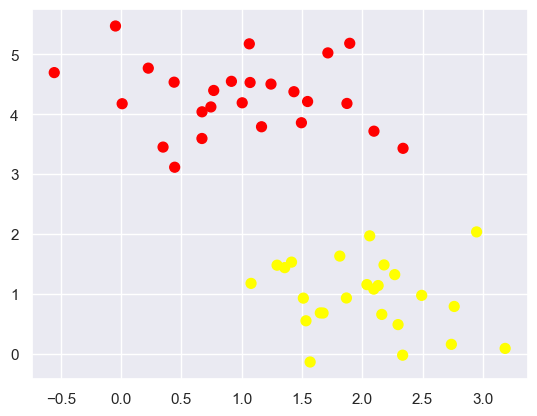

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

In [3]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


In [4]:
class SVM:
    def fit(self, X_train, y_train, num_iterations=1000, learning_rate=0.01, c=0.01):
        # Convert 0's to -1 so loss will be calculated correctly
        y_train = np.where(y_train==0, -1, 1)
        
        num_samples, num_features = X_train.shape
        self.weights = np.zeros(num_features)
        self.bias = 0

        for _ in range(num_iterations):
            for i in range(num_samples):
                x, y = X_train[i], y_train[i]

                loss = self.hinge_loss(x, y)

                # dw of the magnitude
                gradient = 2 * c * self.weights
                if loss > 0:
                    # dw of the loss function
                    gradient -= np.dot(x, y)
                    # db of the loss function
                    self.bias -= learning_rate * -y
                self.weights -= learning_rate * gradient

    # returns max(0, 1 - y(wx + b))
    def hinge_loss(self, x, y):
        return max(0, 1 - y*self.decision_function(x))
    
    # returns wx + b
    def decision_function(self, X):
        return np.dot(X, self.weights) + self.bias

    # returns sign(wx + b)
    def predict(self, X_test):
        return self.sign(np.dot(X_test, self.weights) + self.bias)

    def sign(self, X):
        return np.where(X>=0, 1, 0)

In [5]:
svm_model = SVM()
svm_model.fit(X, y)
svm_model.predict(X)

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0])

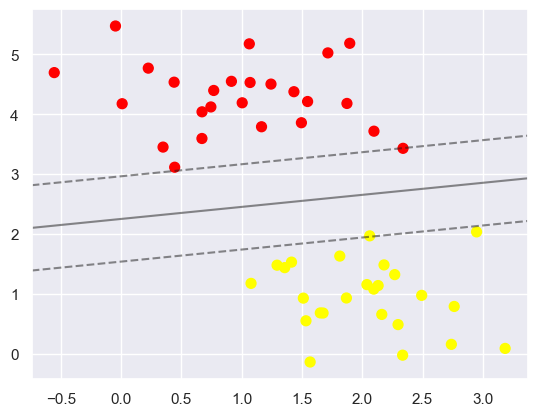

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(svm_model, plot_support=False)

In [7]:
class Perceptron:
    def fit(self, X_train, y_train, num_iterations=1000, learning_rate=0.01):
        # Convert 0's to -1 so loss will be calculated correctly
        y_train = np.where(y_train==0, -1, 1)
        
        num_samples, num_features = X_train.shape
        self.weights = np.random.rand(num_features)
        self.bias = 5*np.random.rand(1)

        for _ in range(num_iterations):
            for i in range(num_samples):
                x, y = X_train[i], y_train[i]

                loss = self.perceptron_loss(x, y)
                if loss > 0:
                    # dw of the loss function
                    self.weights -= learning_rate * -y * x
                    # db of the loss function
                    self.bias -= learning_rate * -y

    # returns max(0, -y(mx + b))
    def perceptron_loss(self, x, y):
        return max(0, -y*self.decision_function(x))

    # returns wx + b
    def decision_function(self, X):
        return np.dot(X, self.weights) + self.bias

    # returns sign(wx + b)
    def predict(self, X_test):
        return self.sign(self.decision_function(X_test))

    def sign(self, X):
        return np.where(X>=0, 1, 0)        

In [8]:
model = Perceptron()
model.fit(X, y)
model.predict(X)

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0])

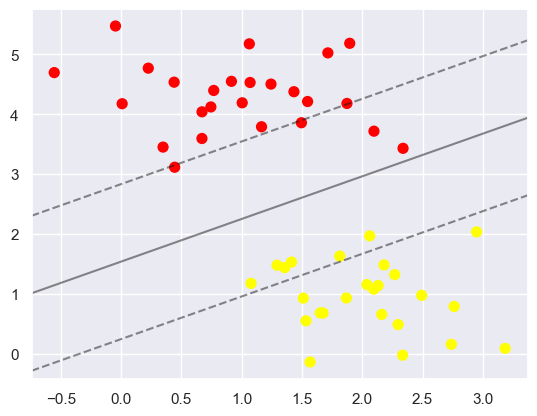

In [9]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model, plot_support=False)